In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob

## Detuning

m100: ['Data\\Jmax70_res008_shiftm100_1000_40000_1.txt', 'Data\\Jmax70_res008_shiftm100_1000_40000_2.txt', 'Data\\Jmax70_res008_shiftm100_1000_40000_3.txt']
means= [3.406 3.41  3.439]
m50: ['Data\\Jmax70_res008_shiftm50_1000_40000_1.txt', 'Data\\Jmax70_res008_shiftm50_1000_40000_2.txt', 'Data\\Jmax70_res008_shiftm50_1000_40000_3.txt']
means= [1.199 1.169 1.241]
000: ['Data\\Jmax70_res008_shift000_1000_40000_1.txt', 'Data\\Jmax70_res008_shift000_1000_40000_2.txt', 'Data\\Jmax70_res008_shift000_1000_40000_3.txt']
means= [0.587 0.564 0.558]
p50: ['Data\\Jmax70_res008_shiftp50_1000_40000_1.txt', 'Data\\Jmax70_res008_shiftp50_1000_40000_2.txt', 'Data\\Jmax70_res008_shiftp50_1000_40000_3.txt']
means= [1.253 1.337 1.254]
p100: ['Data\\Jmax70_res008_shiftp100_1000_40000_1.txt', 'Data\\Jmax70_res008_shiftp100_1000_40000_2.txt', 'Data\\Jmax70_res008_shiftp100_1000_40000_3.txt']
means= [2.252 2.379 2.292]


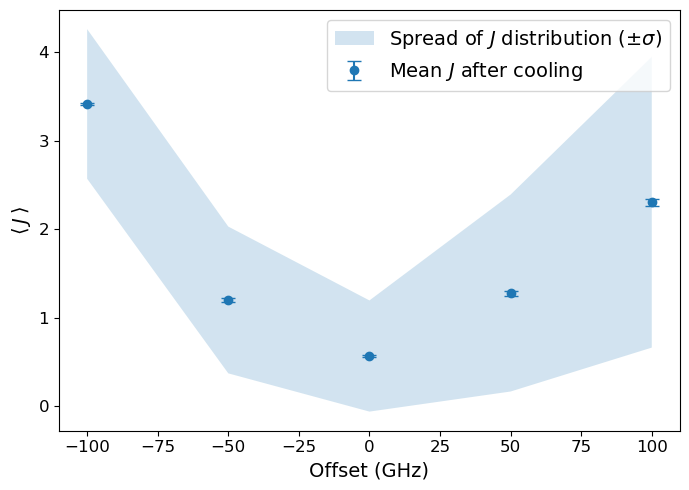

In [51]:
J_max = 70

detuning_labels = ["m100", "m50", "000", "p50", "p100"]
detuning_values = [-100, -50, 0, 50, 100]

J_values = np.arange(J_max + 1)

mean_J_all = []
sem_all = []
std_within_all = []

for label in detuning_labels:

    files = sorted(glob.glob(f"Data/Jmax70_res008_shift{label}_1000_40000_*.txt"))
    print(f"{label}: {files}")

    J_means_runs = []
    
    sum_pop = np.zeros_like(J_values, dtype=float)

    for f in files:
        data = np.loadtxt(f)

        # normierte Population pro Run
        p = data / np.sum(data)

        # Mittelwert pro Run
        J_mean = np.sum(J_values * p)
        J_means_runs.append(J_mean)

        # Population aufsummieren
        sum_pop += p

    J_means_runs = np.array(J_means_runs)
    print("means=", J_means_runs)

    # Mittelwert über Runs
    mean_J_all.append(np.mean(J_means_runs))

    # Standardfehler des Mittelwerts (SEM)
    sem_all.append(np.std(J_means_runs, ddof=1) / np.sqrt(len(J_means_runs)))

    # --------- Streuung aus kombinierter Verteilung ---------

    # Gesamtverteilung normieren
    p_total = sum_pop / np.sum(sum_pop)

    # Mittelwert der Gesamtverteilung
    J_mean_total = np.sum(J_values * p_total)

    # Standardabweichung der Gesamtverteilung
    J_std_total = np.sqrt(np.sum((J_values - J_mean_total)**2 * p_total))

    std_within_all.append(J_std_total)


# Arrays
mean_J_all = np.array(mean_J_all)
sem_all = np.array(sem_all)
std_within_all = np.array(std_within_all)


# --------- Plot ---------

plt.figure(figsize=(7,5))

# Streuung (jetzt aus kombinierter Verteilung)
plt.fill_between(detuning_values,
                 mean_J_all - std_within_all,
                 mean_J_all + std_within_all,
                 alpha=0.2,
                 label=r"Spread of $J$ distribution ($\pm\sigma$)")

# Fehlerbalken (SEM)
plt.errorbar(detuning_values,
             mean_J_all,
             yerr=sem_all,
             fmt='o',
             capsize=5,
             label=r"Mean $J$ after cooling")

plt.xlabel("Offset (GHz)", fontsize=14)
plt.ylabel(r"$\langle\: J \:\rangle$", fontsize=14)
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig("dependence_shift.pdf")
plt.show()

## Resolution

008: ['Data\\Jmax70_res008_shift000_1000_40000_1.txt', 'Data\\Jmax70_res008_shift000_1000_40000_2.txt', 'Data\\Jmax70_res008_shift000_1000_40000_3.txt']
means= [0.587 0.564 0.558]
020: ['Data\\Jmax70_res020_shift000_1000_40000_1.txt', 'Data\\Jmax70_res020_shift000_1000_40000_2.txt', 'Data\\Jmax70_res020_shift000_1000_40000_3.txt']
means= [0.55  0.559 0.513]
060: ['Data\\Jmax70_res060_shift000_1000_40000_1.txt', 'Data\\Jmax70_res060_shift000_1000_40000_2.txt', 'Data\\Jmax70_res060_shift000_1000_40000_3.txt']
means= [1.205 1.166 1.22 ]
100: ['Data\\Jmax70_res100_shift000_1000_40000_1.txt', 'Data\\Jmax70_res100_shift000_1000_40000_2.txt', 'Data\\Jmax70_res100_shift000_1000_40000_3.txt']
means= [1.604 1.667 1.603]
140: ['Data\\Jmax70_res140_shift000_1000_40000_1.txt', 'Data\\Jmax70_res140_shift000_1000_40000_2.txt', 'Data\\Jmax70_res140_shift000_1000_40000_3.txt']
means= [2.089 2.111 2.015]


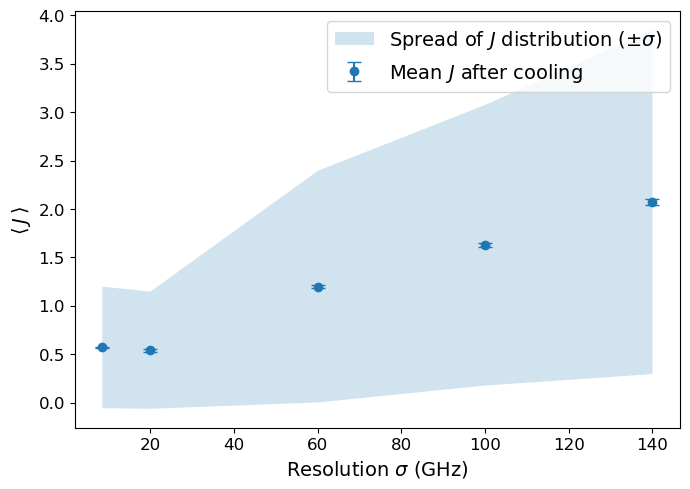

In [52]:
J_max = 70

resolution_labels = ["008", "020", "060", "100", "140"]
resolution_values = [8.5, 20, 60, 100, 140]

J_values = np.arange(J_max + 1)

mean_J_all = []
sem_all = []
std_within_all = []

for label in resolution_labels:

    files = sorted(glob.glob(f"Data/Jmax70_res{label}_shift000_1000_40000_*.txt"))
    print(f"{label}: {files}")

    J_means_runs = []
    
    sum_pop = np.zeros_like(J_values, dtype=float)

    for f in files:
        data = np.loadtxt(f)

        # normierte Population pro Run
        p = data / np.sum(data)

        # Mittelwert pro Run
        J_mean = np.sum(J_values * p)
        J_means_runs.append(J_mean)

        # Population aufsummieren
        sum_pop += p

    J_means_runs = np.array(J_means_runs)
    print("means=", J_means_runs)

    # Mittelwert über Runs
    mean_J_all.append(np.mean(J_means_runs))

    # Standardfehler des Mittelwerts (SEM)
    sem_all.append(np.std(J_means_runs, ddof=1) / np.sqrt(len(J_means_runs)))

    # --------- Streuung aus kombinierter Verteilung ---------

    # Gesamtverteilung normieren
    p_total = sum_pop / np.sum(sum_pop)

    # Mittelwert der Gesamtverteilung
    J_mean_total = np.sum(J_values * p_total)

    # Standardabweichung der Gesamtverteilung
    J_std_total = np.sqrt(np.sum((J_values - J_mean_total)**2 * p_total))

    std_within_all.append(J_std_total)


# Arrays
mean_J_all = np.array(mean_J_all)
sem_all = np.array(sem_all)
std_within_all = np.array(std_within_all)


# --------- Plot ---------

plt.figure(figsize=(7,5))

# Streuung (jetzt aus kombinierter Verteilung)
plt.fill_between(resolution_values,
                 mean_J_all - std_within_all,
                 mean_J_all + std_within_all,
                 alpha=0.2,
                 label=r"Spread of $J$ distribution ($\pm\sigma$)")

# Fehlerbalken (SEM)
plt.errorbar(resolution_values,
             mean_J_all,
             yerr=sem_all,
             fmt='o',
             capsize=5,
             label=r"Mean $J$ after cooling")

plt.xlabel(r"Resolution $\sigma$ (GHz)", fontsize=14)
plt.ylabel(r"$\langle\: J \:\rangle$", fontsize=14)
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig("dependence_resolution.pdf")
plt.show()